### Librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Hipotesis



- A mayor edad del futbolista (player_age), mayor es la cantidad de días (Days) necesarios para recuperarse de una misma lesión.




### ETL

In [3]:
df = pd.read_csv('futbol.csv')
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado: 15603 filas, 11 columnas


In [4]:
df.head()

,Season,Injury,Days,Games missed,injury_from_parsed,injury_until_parsed,player_name,player_age,player_position,club,league
0,20/21,Syndesmosis ligament tear,43 days,9,1/28/2021,3/11/2021,Alexander Nübel,24,Goalkeeper,Bayern Munich,Bundesliga
1,20/21,Knee injury,37 days,6,3/7/2021,4/12/2021,Ron-Thorben Hoffmann,22,Goalkeeper,Bayern Munich,Bundesliga
2,20/21,Corona virus,21 days,4,2/17/2021,3/9/2021,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
3,20/21,bruise,8 days,2,11/6/2020,11/13/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
4,20/21,Ligament injury,22 days,2,7/26/2020,8/16/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15603 entries, 0 to 15602
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Season               15603 non-null  str  
 1   Injury               15603 non-null  str  
 2   Days                 15603 non-null  str  
 3   Games missed         15603 non-null  int64
 4   injury_from_parsed   15603 non-null  str  
 5   injury_until_parsed  15603 non-null  str  
 6   player_name          15603 non-null  str  
 7   player_age           15603 non-null  int64
 8   player_position      15603 non-null  str  
 9   club                 15603 non-null  str  
 10  league               15603 non-null  str  
dtypes: int64(2), str(9)
memory usage: 2.6 MB


In [6]:
total_nulos = df.isnull().sum().sum()
print(f"Cantidad total de valores nulos: {total_nulos}")

Cantidad total de valores nulos: 0


In [7]:
cantidad_duplicados = df.duplicated().sum()
print(f"Cantidad de registros duplicados: {cantidad_duplicados}")

Cantidad de registros duplicados: 0


In [8]:
#Valores únicos por columna
df.nunique()

Season                    5
Injury                  276
Days                    374
Games missed             77
injury_from_parsed     1729
injury_until_parsed    1737
player_name            4081
player_age               28
player_position          14
club                    145
league                    5
dtype: int64

##### Grafico de Distribucion de Edades

In [14]:
# Distribucion de las edades
df["player_age"].describe()

count    15603.000000
mean        26.550663
std          4.398164
min         16.000000
25%         23.000000
50%         26.000000
75%         30.000000
max         43.000000
Name: player_age, dtype: float64

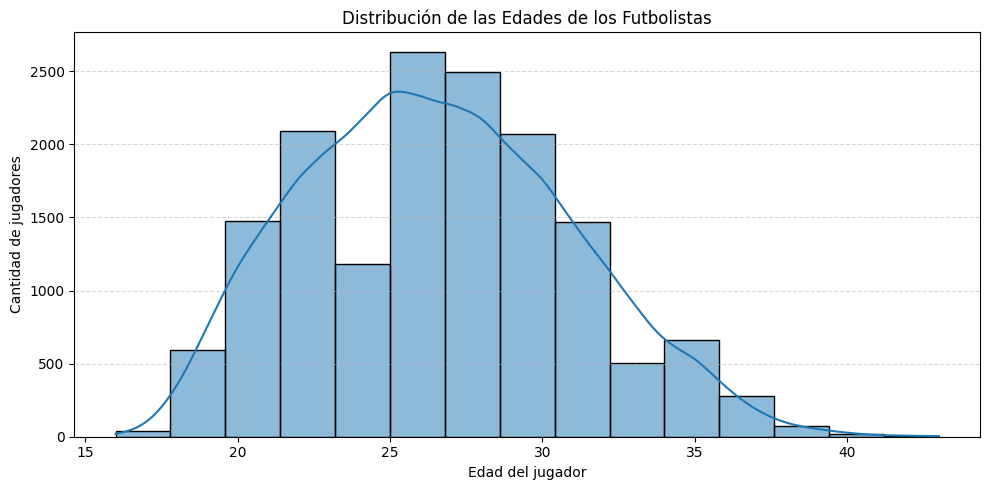

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="player_age",
    bins=15,
    kde=True,
    color="#1f77b4"
)

plt.title("Distribución de las Edades de los Futbolistas")
plt.xlabel("Edad del jugador")
plt.ylabel("Cantidad de jugadores")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

La distribución de edades de los futbolistas se concentra principalmente entre los 20 y 30 años, con un pico alrededor de los 25-27 años. Mientras que los casos de edades más bajas o más altas son menos frecuentes.

##### Grafico 10 lesiones mas frecuentes

Top 10 lesiones más frecuentes:
Injury
Hamstring injury     1256
Corona virus          986
Muscle injury         960
muscular problems     940
Knee injury           584
Ill                   578
Ankle injury          572
Knock                 441
Calf injury           430
Fitness               427
Name: count, dtype: int64


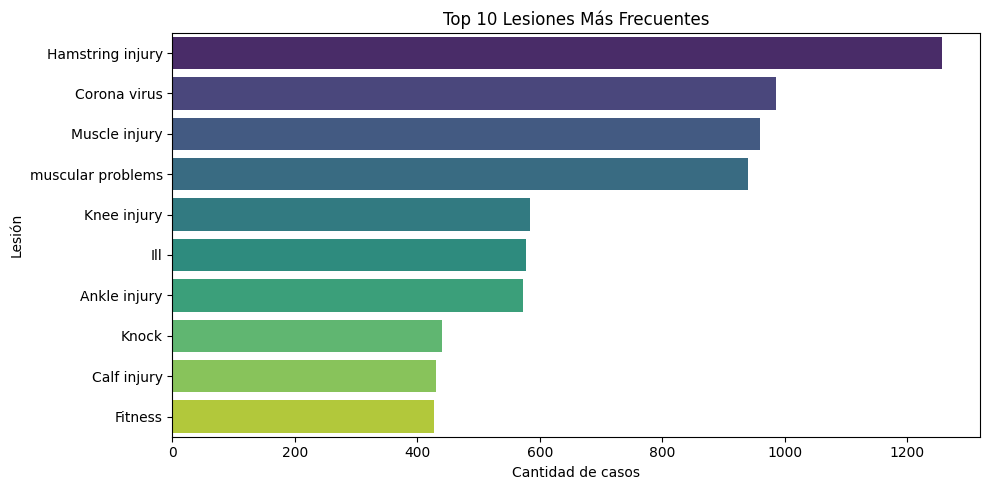

In [11]:
top_10_lesiones = df["Injury"].value_counts().head(10)
print("Top 10 lesiones más frecuentes:")
print(top_10_lesiones)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_10_lesiones.values,
    y=top_10_lesiones.index,
    hue=top_10_lesiones.index,
    palette="viridis",
    legend=False,
)
plt.title("Top 10 Lesiones Más Frecuentes")
plt.xlabel("Cantidad de casos")
plt.ylabel("Lesión")
plt.tight_layout()
plt.show()

In [12]:
#traduccion_lesiones = {
    "Hamstring injury": "Lesión en los isquiotibiales",
    "Corona virus": "Coronavirus",
    "Muscle injury": "Lesión muscular",
    "muscular problems": "Problemas musculares",
    "Knee injury": "Lesión de rodilla",
    "Ill": "Enfermedad",
    "Ankle injury": "Lesión de tobillo",
    "Knock": "Golpe / Contusión",
    "Calf injury": "Lesión en la pantorrilla",
    "Fitness": "Falta de ritmo físico",
}

IndentationError: unexpected indent (1125137646.py, line 2)

##### Grafico Edad vs Lesion

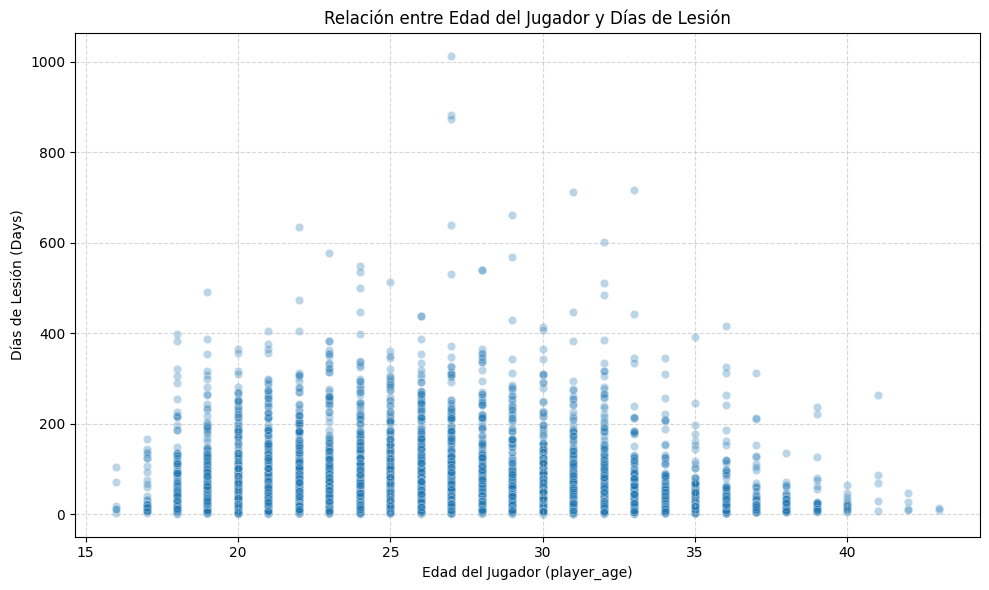

In [16]:
#Limpiar la columna 'Days' extrayendo el número y convirtiendo a int
df["Days_num"] = df["Days"].str.extract(r"(\d+)").astype(int)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="player_age",
    y="Days_num",
    alpha=0.3,
    color="#1f77b4",
)

plt.title("Relación entre Edad del Jugador y Días de Lesión")
plt.xlabel("Edad del Jugador (player_age)")
plt.ylabel("Días de Lesión (Days)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

El gráfico muestra las 10 lesiones más frecuentes en el dataset. Las más comunes son las de isquiotibiales, virus, músculos y rodilla, lo que sugiere que los problemas de carga muscular y de articulaciones predominan entre los futbolistas analizados.

3 casos por arriba de los 800 dias

In [17]:
#Dias de lesión mayores a 800
casos_extremos = df[df["Days_num"] > 800][
    [
        "player_name",
        "player_age",
        "club",
        "league",
        "Injury",
        "Days",
        "Games missed",
        "Season",
    ]
]

casos_extremos

#Knee injury - Lesión de rodilla
#Knee surgery - Cirugía de rodilla

,player_name,player_age,club,league,Injury,Days,Games missed,Season
4784,Jack O'Connell,27,Sheffield United,Premier League,Knee injury,1013 days,145,20/21
5477,Kortney Hause,27,Aston Villa,Premier League,Knee surgery,883 days,131,22/23
7896,Martín Merquelanz,27,Rayo Vallecano,La Liga,Knee injury,874 days,126,21/22


* **Jack O'Connell (Sheffield United)**: Sufrió una grave lesión en el cartílago de la rodilla en septiembre de 2020. Tuvo múltiples cirugías y complicaciones durante su proceso de rehabilitación que le impidieron volver a jugar un partido oficial, hasta que finalmente anunció su retiro profesional prematuro.

* **Martín Merquelanz (Rayo Vallecano / Real Sociedad)**: En septiembre de 2021, durante un partido frente al Levante, sufrió una severa lesión del cartílago articular de la rodilla izquierda. Atravesó un calvario de casi dos años y medio de operaciones y recuperación hasta poder reincorporarse a los entrenamientos.

* **Kortney Hause (Aston Villa / Watford)**: Tuvo que someterse a una cirugía de rodilla a finales de 2022 mientras estaba a préstamo. La recuperación se complicó prolongadamente dejándolo fuera de competencia durante más de dos años sin poder disputar minutos oficiales con el primer equipo.

##### Grafico Promedio de días de recuperación según cada edad

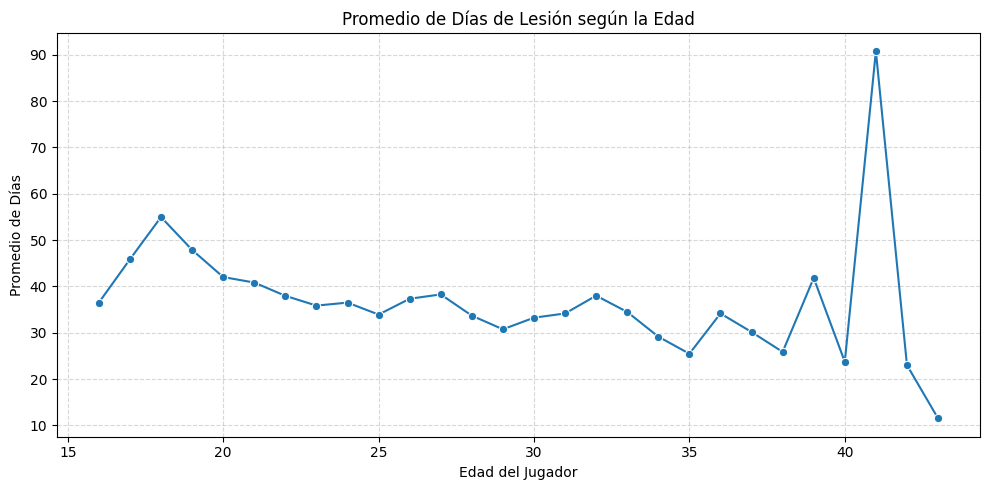

In [18]:
# Promedio de días de recuperación según cada edad
dias_por_edad = df.groupby("player_age")["Days_num"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=dias_por_edad, x="player_age", y="Days_num", marker="o")
plt.title("Promedio de Días de Lesión según la Edad")
plt.xlabel("Edad del Jugador")
plt.ylabel("Promedio de Días")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

El promedio de días de lesión varía entre las distintas edades, sin mostrar una tendencia lineal claramente creciente. Por lo tanto, este gráfico no permite confirmar que los futbolistas de mayor edad necesiten más tiempo de recuperación.

##### Apuntes

Por hacer

Verificar formato fechas,

Dias de recuperacion por lesion,

Lesiones por posicion,

Lo mismo, pero por cada liga,

Deteccion de outliers,

Posible variable a predecir


"Games missed" - cuántos partidos se perderá un futbolista debido a una lesión?,

"Days" - cuántos días estará lesionado un jugador?